<div style="text-align: center;">
    <a href="https://www.hi-paris.fr/">
        <img border="0" src="https://www.hi-paris.fr/wp-content/uploads/2020/09/logo-hi-paris-retina.png" width="25%"></a>
    <a href="https://www.dataia.eu/">
        <img border="0" src="https://github.com/ramp-kits/template-kit/raw/main/img/DATAIA-h.png" width="70%"></a>
</div>

# Euclid QuenchBench (Q1) codabench challenge

<i> LEFEBVRE Quentin </i><br/>
<i> MORICE Clément </i><br/>
<i> BILLUART Jérémy </i><br/>
<i> DANA GARCIA Paola </i><br/>
<i> POUPONNEAU Thomas </i><br/>
<i> ANSELME Hugo </i>

## Introduction

### Context
Galaxies broadly separate into two populations:

- **Star-forming** galaxies (actively forming stars),
- **Quenched / quiescent** galaxies (star formation has largely stopped).

Understanding **galaxy quenching** is a central problem in galaxy evolution. Euclid provides wide-area multi-band imaging that makes it possible to study these populations statistically across cosmic time.

### Usually, how is this done?

Traditionally, astronomers determine if a galaxy is quenched by estimating its underlying physical properties (like Stellar Mass and Star Formation Rate) using SED (Spectral Energy Distribution) fitting.

**What is SED fitting?**

It is a technique where the observed photometric fluxes of a galaxy across different wavelength bands are compared against a vast grid of theoretical, synthetic galaxy spectra. By finding the best-matching template, astronomers can infer the galaxy's physical properties.

**Why consider Machine Learning (ML) for this?**

SED fitting is notoriously slow and computationally expensive. With Euclid expected to observe billions of galaxies, running full SED fitting for every single object is a massive bottleneck. However, once trained, an ML model can predict the status of millions of galaxies in seconds. Moreover, standard SED fitting relies almost entirely on photometry (fluxes), while ML algorithms can effortlessly ingest diverse types of data, allowing us to combine photometric colors with structural and morphological features to create much more robust predictive models. Also, SED fitting requires assuming specific Initial Mass Functions (IMFs), Star Formation Histories (SFHs), and dust attenuation laws. ML models can learn complex, non-linear empirical relationships directly from the data distribution.

### Where the data comes from
This challenge uses **Euclid Q1** catalogue measurements (photometry + morphology), with optical cross-matches (when available). The features are observables (fluxes, flux errors, morphology), so the task mimics what we can do in real surveys.

### The ML task
This is a **binary classification** problem:

- `y_quenched = 1` → quenched
- `y_quenched = 0` → star-forming

Participants must submit **probabilities** `y_pred = P(y_quenched=1 | features)`.

### Why the task makes sense (physics)
The target is derived from the **specific star formation rate** (sSFR):

$$
\mathrm{sSFR} = \frac{\mathrm{SFR}}{M_*}
$$

A galaxy is labeled quenched if it falls below an evolving threshold motivated by the literature:

$$
\mathrm{sSFR} < \frac{0.3}{t_H(z)} \quad\text{with}\quad t_H(z)=\frac{1}{H(z)}.
$$

where H(z) is the Hubble time (time scale related to the expansion of the universe).

To avoid selection bias, the sample is restricted to a mass-complete regime using a Pozzetti inspired completeness estimate per redshift bin.

### What makes it challenging
- **Class imbalance** (quenched is the minority class in training).
- **Missing data** (e.g., some optical bands are absent for many objects).
- **Domain shift with redshift**: train and test sets are drawn from different redshift ranges, so the feature distribution and class balance change.


# Exploratory data analysis

This section introduces the released tables:

- **`train_features.csv`** + **`train_labels.csv`**: used to fit models
- **`test_features.csv`**: public test (no labels released to participants)
- **`private_test_features.csv`**: private test (used for final ranking)

Features are grouped into:
- **Euclid fluxes + errors** (VIS, Y, J, H) at multiple apertures,
- **Optional optical bands** (u, g, r, i, z) unified from external surveys (may contain NaNs),
- **Morphology / shape** features (size, ellipticity, concentration, Gini, etc.),
- **Galactic extinction proxy** (`gal_ebv`).

Below we inspect shapes, basic statistics, missingness patterns, and a few sanity plots.


In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from ingestion_program.ingestion import load_train

pd.set_option("display.max_columns", None)

data_dir = Path("dev_phase/input_data")

# load train data
X_train, y_train = load_train(data_dir)

print("Train features shape:", X_train.shape)
print("Train labels shape:", y_train.shape)

# Combine by index for EDA
df_train = X_train.copy()
df_train["y_quenched"] = y_train.to_numpy()
print("Merged train shape:", df_train.shape)

display(df_train.head())


Train features shape: (80000, 41)
Train labels shape: (80000,)
Merged train shape: (80000, 42)


,flux_vis_1fwhm_aper,flux_y_1fwhm_aper,flux_j_1fwhm_aper,flux_h_1fwhm_aper,fluxerr_vis_1fwhm_aper,fluxerr_y_1fwhm_aper,fluxerr_j_1fwhm_aper,fluxerr_h_1fwhm_aper,flux_vis_2fwhm_aper,flux_y_2fwhm_aper,flux_j_2fwhm_aper,flux_h_2fwhm_aper,fluxerr_vis_2fwhm_aper,fluxerr_y_2fwhm_aper,fluxerr_j_2fwhm_aper,fluxerr_h_2fwhm_aper,flux_u_opt,flux_g_opt,flux_r_opt,flux_i_opt,flux_z_opt,fluxerr_u_opt,fluxerr_g_opt,fluxerr_r_opt,fluxerr_i_opt,fluxerr_z_opt,opt_source,n_opt,semimajor_axis,ellipticity,kron_radius,fwhm,mu_max,mumax_minus_mag,sersic_fract_vis_disk_sersic,concentration,gini,moment_20,asymmetry,smoothness,gal_ebv,y_quenched
0,0.650706,1.740700,1.893236,2.282246,0.025705,0.116798,0.115489,0.115419,1.376462,4.103703,4.422349,5.051379,0.049293,0.217241,0.206029,0.205294,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1.968851,0.048542,13.781960,1.286191,21.315117,-2.046883,NaN,2.618865,0.539841,-1.565669,0.205787,0.053660,0.048653,0
1,0.419672,1.043393,1.446463,1.777239,0.021666,0.110673,0.107265,0.109009,0.902079,2.535646,3.311208,4.039443,0.042047,0.211063,0.198226,0.201757,NaN,0.130837,0.335355,0.576884,0.724394,NaN,0.020342,0.026878,0.051791,0.100249,1,4,3.118187,0.437422,21.827309,1.234914,22.666941,-1.141836,NaN,2.498685,0.632911,-1.326447,0.086194,0.176906,0.022145,0
2,5.394265,15.815121,22.292292,31.615299,0.046525,0.200394,0.204066,0.246597,13.357740,38.092175,52.545296,74.029167,0.086440,0.338194,0.335310,0.396808,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,7.372054,0.127115,51.604378,1.597588,20.109900,-0.488180,NaN,3.505604,0.568984,-2.192318,0.136747,0.159070,0.067541,1
3,0.472359,1.087087,1.589563,1.697908,0.023816,0.111871,0.103905,0.111533,1.070891,2.522372,3.873844,3.833501,0.046489,0.217239,0.197309,0.212182,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,3.603850,0.291081,25.226950,1.182586,22.753895,-0.656364,NaN,2.053760,0.570039,-1.264059,0.390451,0.183670,0.049362,0
4,0.543285,0.761267,0.869244,0.950455,0.027031,0.119458,0.104170,0.106690,1.422376,2.024553,2.329649,2.638041,0.053892,0.236688,0.204772,0.209915,NaN,0.329230,0.533266,0.603092,0.716561,NaN,0.024100,0.032750,0.063957,0.116799,1,4,4.801898,0.399365,33.613289,1.306142,23.212400,0.255125,NaN,2.659560,0.663547,-1.686537,0.194653,0.225379,0.014933,0


### Imbalance

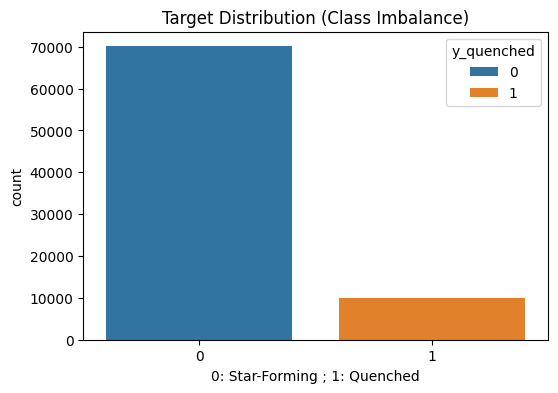

Fraction of Quenched galaxies in Train: 12.39%


In [27]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_train, x="y_quenched", hue="y_quenched", palette="tab10")
plt.title("Target Distribution (Class Imbalance)")
plt.xlabel("0: Star-Forming ; 1: Quenched")
plt.show()

quenched_frac = df_train['y_quenched'].mean()
print(f"Fraction of Quenched galaxies in Train: {quenched_frac:.2%}")

### Missing values

Top 10 features with most missing values (%):
fluxerr_u_opt                   100.00000
sersic_fract_vis_disk_sersic    100.00000
flux_u_opt                      100.00000
fluxerr_r_opt                    31.98125
flux_r_opt                       31.98125
flux_i_opt                       31.89750
fluxerr_i_opt                    31.89750
flux_z_opt                       31.68375
fluxerr_z_opt                    31.68375
fluxerr_g_opt                    31.52500
dtype: float64


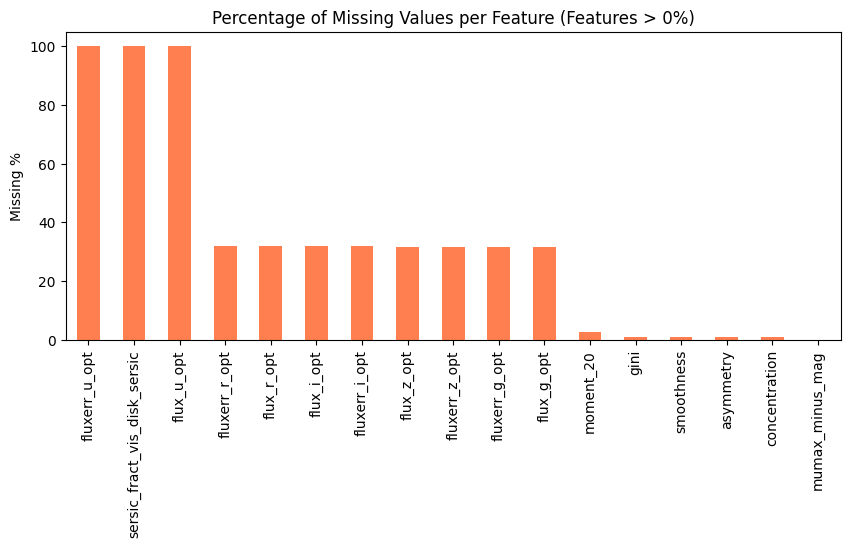

In [42]:
missing_pct = df_train.isnull().mean().sort_values(ascending=False) * 100
print("Top 10 features with most missing values (%):")
print(missing_pct.head(10))

plt.figure(figsize=(10, 4))
missing_pct[missing_pct > 0].plot(kind='bar', color='coral')
plt.title("Percentage of Missing Values per Feature (Features > 0%)")
plt.ylabel("Missing %")
plt.show()

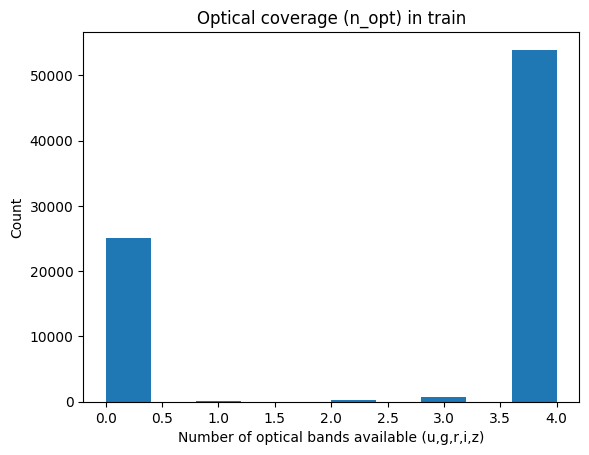

In [44]:
# A quick view of how many optical bands are present
if "n_opt" in df_train.columns:
    fig = plt.figure()
    plt.hist(df_train["n_opt"].values)
    plt.title("Optical coverage (n_opt) in train")
    plt.xlabel("Number of optical bands available (u,g,r,i,z)")
    plt.ylabel("Count")
    plt.show()

### Color-Magnitude Diagram

Raw fluxes are hard to interpret. Astronomers convert fluxes to AB Magnitudes (a logarithmic scale where smaller numbers mean brighter objects) and compute colors (the difference between two magnitudes). 

Quenched galaxies no longer form hot, blue stars. They are dominated by old, cool, red stars. Let's see if we can spot something


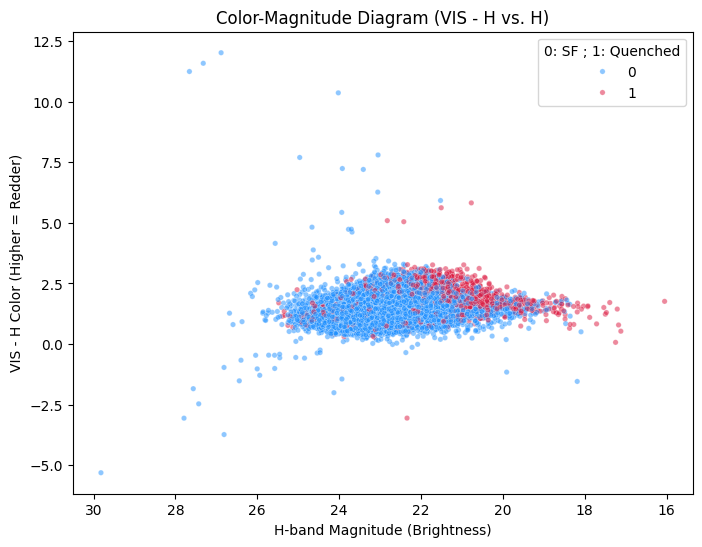

In [46]:
# Convert flux (microJanskys) to AB Magnitude
def flux_to_mag(flux):
    return -2.5 * np.log10(np.clip(flux, 1e-6, None)) + 23.9

# Create features
df_train["mag_vis"] = flux_to_mag(df_train["flux_vis_1fwhm_aper"])
df_train["mag_h"] = flux_to_mag(df_train["flux_h_1fwhm_aper"])
df_train["color_vis_h"] = df_train["mag_vis"] - df_train["mag_h"]

# Plot CMD (using a subsample for visual clarity)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_train.sample(10000, random_state=42), 
    x="mag_h", 
    y="color_vis_h", 
    hue="y_quenched", 
    palette={0: "dodgerblue", 1: "crimson"}, 
    alpha=0.5, 
    s=15
)
plt.gca().invert_xaxis()
plt.title("Color-Magnitude Diagram (VIS - H vs. H)")
plt.xlabel("H-band Magnitude (Brightness)")
plt.ylabel("VIS - H Color (Higher = Redder)")
plt.legend(title="0: SF ; 1: Quenched")
plt.show()

The red points (Quenched) clearly at higher brightness but there is not big difference is colors (redder or not). There is a significant overlap so photometry features alone isn't always enough.

### Morphology : the shape of galaxies

When a galaxy dies (quenches), its structure often changes from a flat, star-forming disk to a round, featureless blob (elliptical). Let's look at non-parametric morphological features like the Gini coefficient (how unevenly the light is distributed) and the FWHM (Full Width at Half Maximum, a proxy for size/concentration).

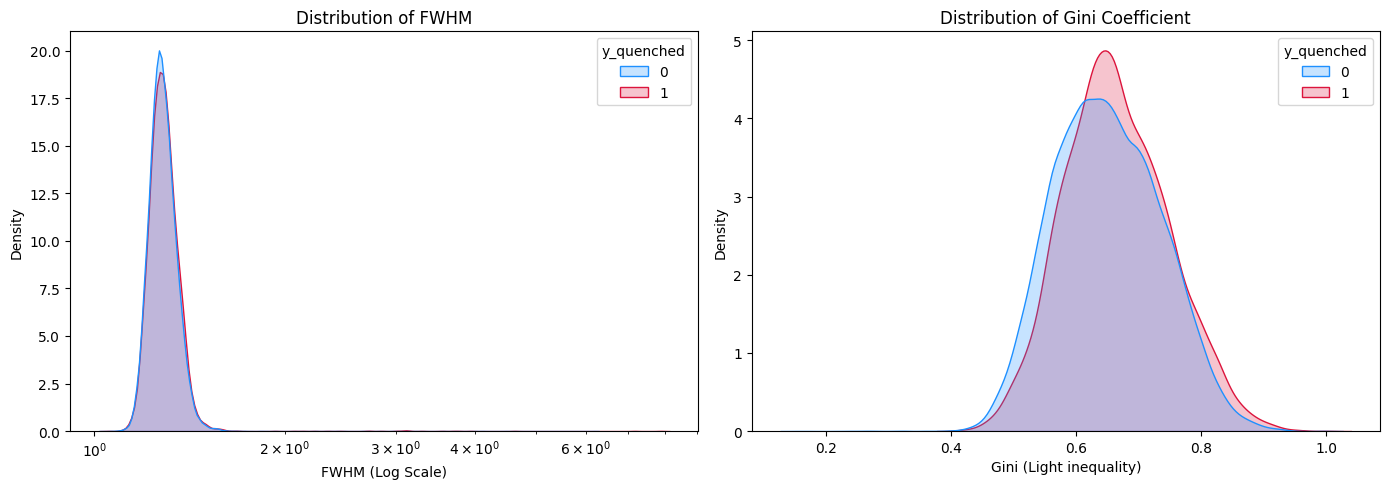

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FWHM (Size/Concentration)
sns.kdeplot(
    data=df_train, x="fwhm", hue="y_quenched", 
    common_norm=False, fill=True, 
    palette={0: "dodgerblue", 1: "crimson"}, 
    ax=axes[0], log_scale=True
)
axes[0].set_title("Distribution of FWHM")
axes[0].set_xlabel("FWHM (Log Scale)")

# Gini Coefficient
sns.kdeplot(
    data=df_train, x="gini", hue="y_quenched", 
    common_norm=False, fill=True, 
    palette={0: "dodgerblue", 1: "crimson"}, 
    ax=axes[1]
)
axes[1].set_title("Distribution of Gini Coefficient")
axes[1].set_xlabel("Gini (Light inequality)")

plt.tight_layout()
plt.show()

As you can see, FWHM is not that informative but quenched galaxies tend to have a higher Gini coefficient (light is highly concentrated in the center, typical of elliptical bulges). 

So from these few EDA steps, you see that combining photometry and morphology features together using advanced Machine Learning is the key to mastering the Redshift Drift and winning this challenge !

# Challenge evaluation

The submission is evaluated on the **public test** (dev phase) and on a **private test** (final ranking).

Because the data are **imbalanced** and the distribution changes with **redshift**, we use metrics that are:

- **Probability-based**,
- **Imbalance-aware**,
- **Robust to redshift/domain shift**.

## Metrics used
We report three metrics for each evaluated set:

### 1) Primary : Redshift-macro class-balanced log loss
We compute a **class-balanced weighted log loss** within each redshift bin and then average across bins (each bin has equal weight).  
This prevents models from performing well only on the easiest/redshift-dominant part of the test distribution.

### 2) Secondary : AUPRC / Average Precision
The area under the precision–recall curve focuses on recovering the minority class (quenched) under imbalance.

### 3) Tertiary : Recall at 85% precision
Astronomy often reports **purity** (precision) and **completeness** (recall).  
This metric answers: *“How many quenched galaxies can we recover while keeping purity ≥ 85%?”*

**Important:** the primary metric expects **probabilities** y_pred (not hard labels).


# Submission format

You must submit a CSV file containing **one probability per object**:

- File name (Codabench): `test_predictions.csv` (and similarly `private_test_predictions.csv` is produced by the ingestion program).
- Columns required:

| column | meaning |
|---|---|
| `object_id` | galaxy identifier (must match the provided test set IDs) |
| `y_pred` | predicted probability that the galaxy is **quenched** (`P(y_quenched=1)`) |

Example:

```text
object_id,y_pred
12345,0.083
12346,0.912
12347,0.301
```

Values must satisfy `0 ≤ y_pred ≤ 1`.


## A simple baseline model

Below is a lightweight baseline that:

- handles **missing values**,
- outputs **probabilities**,
- is fast enough for a starting kit.

Feel free to replace it with stronger models (e.g., gradient boosting, calibrated models, feature engineering).


In [ ]:
# %load solution/submission.py
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline


def get_model():
    return Pipeline([
        ("gradboost_sk", HistGradientBoostingClassifier(max_iter=200, class_weight="balanced", random_state=0)),
    ])


## Local testing pipeline

This section shows how to:

1. Train the baseline on the training set,
2. Predict **probabilities** on the public test set,
3. Compute the three metrics locally (if the public test labels are available in your local folder),
4. Write a submission file `test_predictions.csv`.


In [48]:
# remove sklearn warning about y_true being all 0s or all 1s in a bin
import warnings
warnings.filterwarnings("ignore")

model = get_model()

data_dir = Path("dev_phase/input_data")

X_train, y_train = load_train(data_dir)
model.fit(X_train, y_train)

X_test = pd.read_csv("dev_phase/input_data/test/test_features.csv")
from ingestion_program.ingestion import predict_with_ids
y_test = predict_with_ids(model, X_test)

from scoring_program.scoring import macro_redshift_weighted_log_loss, recall_at_precision
from sklearn.metrics import average_precision_score

pred_df = y_test.copy()
labels_df = pd.read_csv("dev_phase/reference_data/test_labels.csv")

labels_df["object_id"] = labels_df["object_id"].astype("string").str.strip()
pred_df["object_id"] = pred_df["object_id"].astype("string").str.strip()

eval_df = labels_df.merge(pred_df, on="object_id", how="inner", validate="one_to_one")

print(
    "Macro Redshift-Weighted Log Loss on test set:",
    macro_redshift_weighted_log_loss(
        eval_df,
        y_col="y_quenched",
        p_col="p_quenched",
        zbin_col="z_bin",
    ),
)

print(
    "Average Precision on test set:",
    average_precision_score(
        eval_df["y_quenched"],
        eval_df["p_quenched"],
    ),
)

print(
    "Recall at Precision >= 0.85 on test set:",
    recall_at_precision(
            y = eval_df["y_quenched"],
            p = eval_df["p_quenched"],
        target_precision=0.85,
    ),
)

Macro Redshift-Weighted Log Loss on test set: 0.6153922882746063
Average Precision on test set: 0.4471663004981793
Recall at Precision >= 0.85 on test set: 0.010894235133908307


## Submission

- Submit the generated `test_predictions.csv` to the platform.
- The ingestion program will run your code and produce predictions for both `test` and `private_test`.
- The platform will display public leaderboard results on the **public test** set.
- Final ranking uses the **private test** set.